In [ ]:
# ── Imports (robust version, independent of the package structure) ──
import os
import importlib.util
import numpy as np
import matplotlib.pyplot as plt

# ABSOLUTE or notebook-relative path to your NeuralNetwork.py file
neuralnet_path = 'NeuralNetwork.py'

spec   = importlib.util.spec_from_file_location("NeuralNetwork", neuralnet_path)
NeuralNetwork = importlib.util.module_from_spec(spec)
spec.loader.exec_module(NeuralNetwork)

NeuralNetModel = NeuralNetwork.NeuralNetModel

In [ ]:
# ── Convergence Curve (§4.1) ─────────────────────────────────────────

def refold_counts(photons: np.ndarray, srm_flat: np.ndarray,
                   n_true: int, n_det: int) -> np.ndarray:
    """
    Re-projects a photon spectrum through its SRM to obtain the
    predicted counts: c_pred = SRM.T @ phi

    Parameters
    ----------
    photons  : ndarray (n_true,) or (N, n_true)
    srm_flat : ndarray (n_true*n_det,) or (N, n_true*n_det)

    Returns
    -------
    ndarray (n_det,) or (N, n_det)
    """
    single = photons.ndim == 1
    if single:
        photons  = photons[np.newaxis, :]
        srm_flat = srm_flat[np.newaxis, :]

    N   = photons.shape[0]
    srm = srm_flat.reshape(N, n_true, n_det)
    c_pred = np.einsum('nij,ni->nj', srm, photons)   # sum over the true-energy axis

    return c_pred[0] if single else c_pred
    
def plot_training_curves(model: 'NeuralNetModel') -> None:
    """Displays train_loss / val_loss (log) and the learning rate over epochs."""
    if not getattr(model, 'train_history', None):
        print("[plot_training_curves] No history available. Call .train() first "
              "(or load a saved model that includes the history).")
        return

    train_history = model.train_history
    val_history   = model.val_history
    lr_history    = model.lr_history
    best_epoch    = getattr(model, 'best_epoch', None)
    epochs        = np.arange(1, len(train_history) + 1)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    ax1.plot(epochs, train_history, label='Train loss')
    ax1.plot(epochs, val_history,   label='Val loss')
    if best_epoch:
        ax1.axvline(best_epoch, color='green', linestyle='--', alpha=0.6,
                     label=f'Best epoch ({best_epoch})')
    ax1.set_yscale('log')
    ax1.set_ylabel('MSE loss')
    ax1.legend()
    ax1.grid(True, which='both', ls='--', alpha=0.4)

    ax2.plot(epochs, lr_history, color='purple')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Learning rate')
    ax2.grid(True, ls='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

In [ ]:
# ── Spectral Comparison + Relative Residuals (§4.2 + §4.3) ────────────

def fit_power_law(e_true: np.ndarray, phi: np.ndarray) -> tuple:
    """
    Estimates (A, alpha) of a spectrum via log-log linear regression:
        log(phi) = log(A) - alpha * log(E)

    Useful for comparing the physical parameters of the predicted
    spectrum to those of the true spectrum (which are known exactly
    at generation time).

    Returns
    -------
    (A_fit, alpha_fit) : tuple of float
    """
    mask = phi > 0
    if mask.sum() < 2:
        return np.nan, np.nan
    slope, intercept = np.polyfit(np.log(e_true[mask]), np.log(phi[mask]), 1)
    A_fit     = np.exp(intercept)
    alpha_fit = -slope
    return A_fit, alpha_fit
    
def plot_test_error(model: 'NeuralNetModel', sample_idx: int = None,
                     rng: np.random.Generator = None) -> None:
    """
    Displays the network's prediction on a test-set sample with:
      - top panel: true vs predicted photon spectrum (log-log)
      - bottom panel: relative error (pred - true) / true  [%]
    """
    if getattr(model, 'X_test', None) is None:
        print("[plot_test_error] No test set available. Call .train() "
              "first (or load a saved model that includes the test set).")
        return

    X_test, Y_test, S_test = model.X_test, model.Y_test, model.S_test
    P_test = getattr(model, 'P_test', None)
    n_test = len(X_test)
    if sample_idx is None:
        generator = rng if rng is not None else np.random.default_rng()
        sample_idx = int(generator.integers(0, n_test))

    counts_sample = X_test[sample_idx]
    true_photons  = Y_test[sample_idx]
    n_true, n_det = model.srm_data['matrix'].shape
    srm_sample    = S_test[sample_idx].reshape(n_true, n_det)

    pred_photons = model.predict(counts_sample, srm=srm_sample)

    e_true = model.srm_data['e_true']

    if P_test is not None:
        A_true, alpha_true = P_test[sample_idx]
    else:
        A_true, alpha_true = np.nan, np.nan
    A_pred, alpha_pred = fit_power_law(e_true, pred_photons)

    safe_true = np.where(true_photons > 0, true_photons, np.nan)
    rel_error = (pred_photons - true_photons) / safe_true * 100

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7),
                                   sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    fig.suptitle(f"CNN — test sample #{sample_idx} / {n_test}", fontsize=12)

    ax1.step(e_true, true_photons, where='mid', color='green',
             label=f'True spectrum (A={A_true:.3e}, α={alpha_true:.2f})')
    ax1.step(e_true, pred_photons, where='mid', color='orange', linestyle='--',
             label=f'Predicted spectrum (A={A_pred:.3e}, α={alpha_pred:.2f})')
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_ylabel('Photon flux [ph / (s cm² keV)]')
    ax1.legend()
    ax1.grid(True, which='both', ls='--', alpha=0.4)

    ax2.step(e_true, rel_error, where='mid', color='red', label='Relative error')
    ax2.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax2.set_xscale('log')
    ax2.set_xlabel('Energy (keV)')
    ax2.set_ylabel('(pred − true) / true  [%]')
    ax2.legend()
    ax2.grid(True, which='both', ls='--', alpha=0.4)

    plt.tight_layout()
    plt.show()


In [ ]:
# ── Instrumental Consistency Test (§4.4) ───────────────────────────────

def plot_instrumental_consistency(model: 'NeuralNetModel', n_eval: int = None,
                                   rng: np.random.Generator = None) -> None:
    """
    Re-projects the predicted photon spectrum through the current SRM:
        X_reprojected = R_current @ Y_predicted
    then plots the correlation line between X_observed and X_reprojected.
    """
    if getattr(model, 'X_test', None) is None:
        print("[plot_instrumental_consistency] No test set available. "
              "Call .train() first (or load a saved model that includes the test set).")
        return

    X_test, Y_test, S_test = model.X_test, model.Y_test, model.S_test
    n_true, n_det = model.srm_data['matrix'].shape
    n_test = len(X_test)

    if n_eval is None or n_eval > n_test:
        n_eval = n_test
    generator = rng if rng is not None else np.random.default_rng()
    idx = (generator.choice(n_test, size=n_eval, replace=False)
           if n_eval < n_test else np.arange(n_test))

    counts_obs = X_test[idx]
    srm_sub    = S_test[idx]

    pred_photons = model.predict(counts_obs, srm=srm_sub.reshape(n_eval, n_true, n_det))
    X_reproj     = refold_counts(pred_photons, srm_sub, n_true, n_det)

    x_obs    = counts_obs.ravel()
    x_reproj = X_reproj.ravel()

    coeffs = np.polyfit(x_obs, x_reproj, 1)
    x_line = np.array([x_obs.min(), x_obs.max()])
    y_line = coeffs[0] * x_line + coeffs[1]
    r = np.corrcoef(x_obs, x_reproj)[0, 1]

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(x_obs, x_reproj, s=8, alpha=0.3, color='steelblue',
               label=f'Samples (r = {r:.4f})')
    ax.plot(x_line, x_line, color='black', linestyle='--', linewidth=1.2,
            label='y = x (perfect agreement)')
    ax.plot(x_line, y_line, color='red', linewidth=1.5,
            label=f'Regression: y = {coeffs[0]:.3f}x + {coeffs[1]:.2f}')
    ax.set_xlabel('$X_{observed}$ (counts)')
    ax.set_ylabel('$X_{reprojected}$ (counts)')
    ax.set_title(f"Instrumental Consistency Test — {n_eval} test samples")
    ax.legend()
    ax.grid(True, ls='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

In [ ]:
# ── Loading the trained model ────────────────────────────
model_path = os.path.join('..', '..', '..', '..', 'data', 'nn_powerlaw.pt')
model = NeuralNetModel.load(model_path)

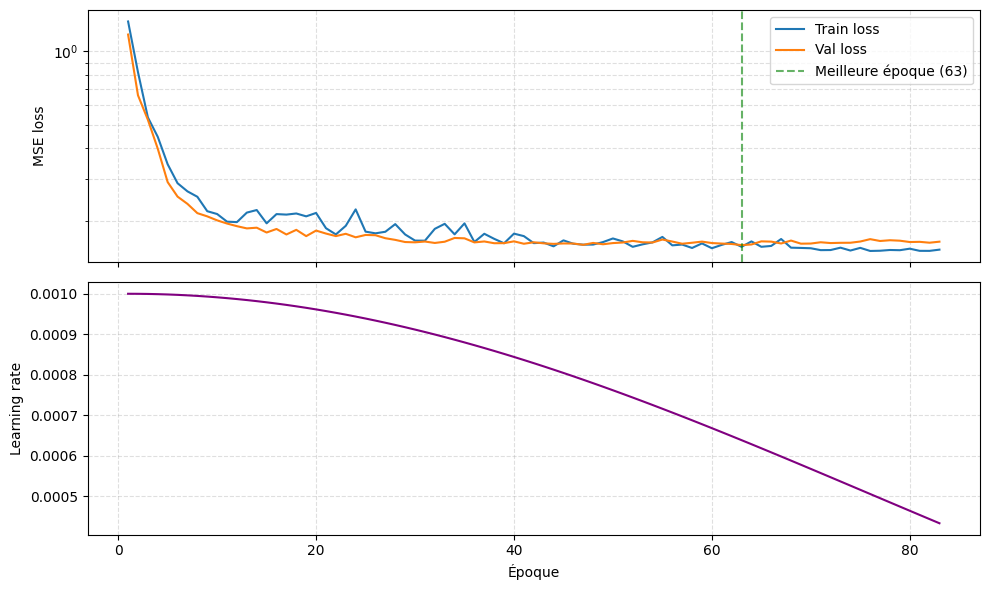

In [7]:
plot_training_curves(model)

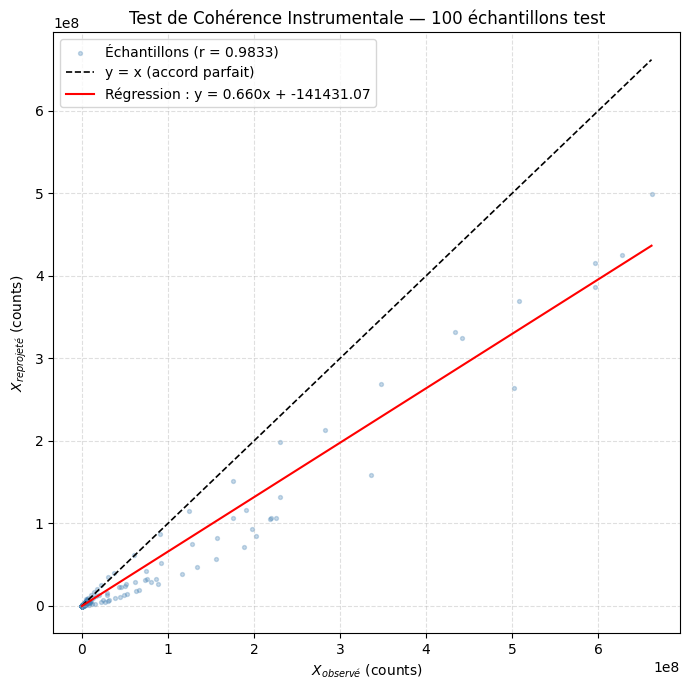

In [12]:
plot_instrumental_consistency(model)

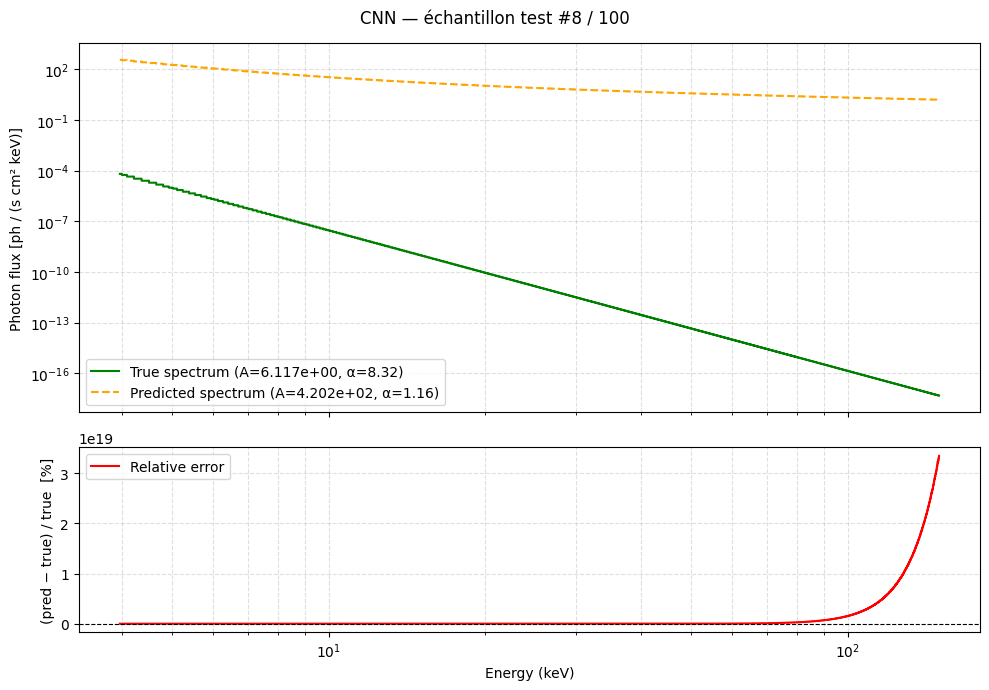

In [13]:
plot_test_error(model)